En este notebook se utiliza un árbol de decisión para predecir si un préstamo será aprobado o no.  
Se crea un dataset con la información de los clientes (edad, ingresos y deuda), se entrena el modelo y se hacen predicciones sobre nuevos casos.

Imports:

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

Creacion del dataset:


In [2]:
data = {
    "Age": [25,28,32,35,45,52,23,40,48],
    "Income": [30,35,40,50,60,65,28,55,62],
    "Debt": [5,12,8,15,10,20,4,18,9],
    "Loan": ["Yes","No","Yes","No","Yes","No","Yes","No","Yes"]
}

df = pd.DataFrame(data)
df

,Age,Income,Debt,Loan
0,25,30,5,Yes
1,28,35,12,No
2,32,40,8,Yes
3,35,50,15,No
4,45,60,10,Yes
5,52,65,20,No
6,23,28,4,Yes
7,40,55,18,No
8,48,62,9,Yes


Variables:

In [3]:
X = df[["Age","Income","Debt"]]  # Variables de entrada
y = df["Loan"]                   # Lo que queremos predecir

Creacion y entrenamiento del modelo:

In [4]:
model = DecisionTreeClassifier()
model.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

Dibujar el árbol de decisión:

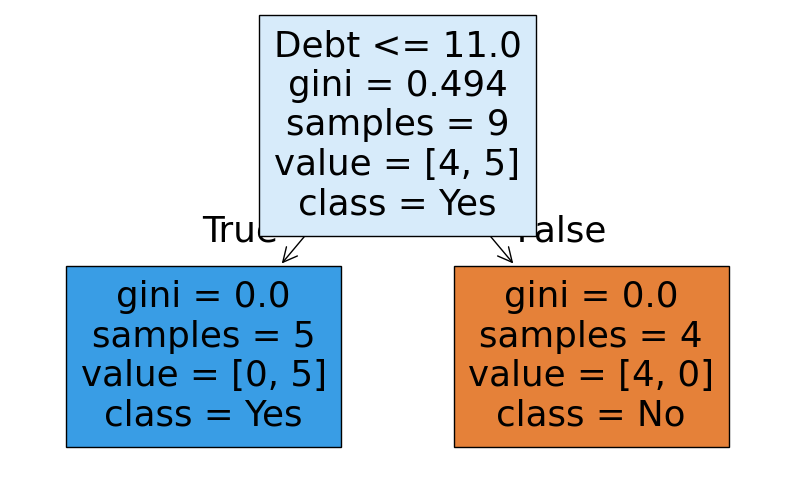

In [5]:
plt.figure(figsize=(10,6))

tree.plot_tree(
    model,
    feature_names=["Age","Income","Debt"],
    class_names=["No","Yes"],
    filled=True
)

plt.show()

Hacer predicciones:

In [6]:
cases = pd.DataFrame({
    "Age":[30,41,50],
    "Income":[45,60,70],
    "Debt":[9,16,7]
})

predictions = model.predict(cases)
print(predictions)

['Yes' 'No' 'Yes']


Conclusión

El modelo de árbol de decisión aprende del dataset que la variable Debt (deuda) es la que mejor separa los casos de préstamos aprobados o no aprobados.  
Los nuevos casos se clasifican correctamente según la regla:  

Debt ≤ 10 → Yes 
Debt > 10 → No

Este notebook muestra cómo usar Python y scikit-learn para crear un árbol de decisión, entrenarlo con datos y hacer predicciones sobre nuevos clientes.